# Purpose of this notebook

Flow Tracking with coronograph imagery has its caveats, even more so with PUNCH WFI whose wide field of view is unprecedented. Projection effects has counter-intuitive consequences, and velocity maps showing km/s should be interpreted with some caveats in mind. This notebook is meant to review some of these caveats. 

Here we go through the preperation steps for correlation-based flow tracking to derive proxies of radial speed over annuli centered on the solar disk. The code optionally go through the download of SOC-provided dataset beforehand - FITS files of L3 PAM V0k data

<img src="flow_maps_time_slices_CME.png" alt="drawing" width="600"/>

Be mindful that the PUNCH data used in this notebook are version v0k. They are not science-ready for the purpose of flow tracking, and are used only to show the general methodology. Some of the processing here may only apply to data version v0k and may not apply to higher calibration versions. 

Author: Raphael Attié 
- rattie@gmu.edu 
- raphael.attie@nasa.gov

Pre-requisite: You must install the `punchbowl` and `opencv-python` package first. Uncomment and run the cell below if you haven't done that yet. 

In [1]:
# %pip install punchbowl
# %pip install opencv-python

Uncomment the two cells below and run them to download the data. We are working with WFI L3 PAM V0k data. 

The date range is from 09-21-2025 00:00:00 to 09-23-2025 00:00:00 UTC

In [1]:
# from sunpy.net import Fido
# from sunpy.net import attrs
# from pathlib import Path
# from datetime import datetime
# from typing import List, Union
# from parfive import Downloader
# import re
# import plotly.express as px

# class PUNCHDataDownloader:
#     """
#     Download PUNCH mission data products using SunPy's Fido interface.

#     Author: Raphael Attie
#     Acknowledgements: Marcus Hughes and Chris Lowder @PUNCH SOC 
#     """

#     def __init__(
#         self,
#         source: str = "PUNCH-MOSAIC",
#         instrument: str = "Unpolarized",
#         base_url: str = "https://umbra.nascom.nasa.gov",
#         start_time: Union[str, datetime] = None,
#         end_time: Union[str, datetime] = None,
#         product_code: str = None,
#         version_code: str = None,
#         output_dir: Union[str, Path] = None
#     ):
#         """
#         Initialize the PUNCH data downloader.

#         Parameters
#         ----------
#         source : str, optional
#             Data source identifier (default: "PUNCH-MOSAIC")
#         instrument : str, optional
#             Instrument name (default: "Unpolarized")
#         base_url : str, optional
#             Prefix HTTP URL to get the data directly from the NASA SDAC
#             (default: "https://umbra.nascom.nasa.gov").
#         start_time : str or datetime, optional
#             Default start time in format 'YYYY/MM/DD HH:MM:SS' or datetime object.
#         end_time : str or datetime, optional
#             Default end time in format 'YYYY/MM/DD HH:MM:SS' or datetime object.
#         product_code : str, optional
#             Default product code identifier ('PTM' or 'PAM').
#         version_code : str, optional
#             Default version code identifier (e.g., 'v0k' to get latest version).
#             This is used to filter out older versions when searching
#             (e.g., keep only files containing 'v0h' and exclude 'v0g' or any other versions indexed by VSO).
#         """
#         self.source = source
#         self.instrument = instrument
#         self.base_url = base_url
#         self.start_time = start_time
#         self.end_time = end_time
#         self.product_code = product_code
#         self.version_code = version_code
#         self.supported_products = ['PAM', 'PTM', 'CTM']
#         if output_dir is None:
#             stime = self.start_time.replace('/', '').replace(':', '').replace(' ', '_')
#             etime = self.end_time.replace('/', '').replace(':', '').replace(' ', '_')
#             self.output_dir = Path('punch_data', stime +'_to_'+etime, self.product_code, self.version_code)
#         else:
#             self.output_dir = Path(output_dir)


#     def search_data(
#         self,
#         start_time: Union[str, datetime] = None,
#         end_time: Union[str, datetime] = None,
#         product_code: str = None,
#         version_code: str = None,
#         return_missing: bool = False
#     ) -> Union[List[str], tuple]:
#         """
#         Search for PUNCH data files directly from the SDAC HTTP server.
        
#         Parameters
#         ----------
#         start_time : str or datetime, optional
#             Start time in format 'YYYY/MM/DD HH:MM:SS' or datetime object
#         end_time : str or datetime, optional
#             End time in format 'YYYY/MM/DD HH:MM:SS' or datetime object
#         product_code : str, optional
#             Product code identifier, can only be 'PTM' or 'PAM'
#         version_code: str, optional
#             Version code identifer (e.g. 'v0k')
#         return_missing: bool, optional
#             If True, also return a list of expected URLs that are missing from the server
            
#         Returns
#         -------
#         List[str] or (List[str], List[str])
#             List of URLs for matching data files. 
#             If return_missing is True, returns a tuple (existing_urls, missing_urls).
#         """
#         import urllib.request
#         import urllib.error
#         import re
#         from datetime import timedelta

#         start_time = start_time or self.start_time
#         end_time = end_time or self.end_time
#         product_code = product_code or self.product_code
#         version_code = version_code or self.version_code

#         if not all([start_time, end_time, product_code, version_code]):
#             raise ValueError("start_time, end_time, product_code, and version_code must be provided either at instantiation or when calling this method.")

#         if isinstance(start_time, str):
#             start_time = datetime.strptime(start_time, '%Y/%m/%d %H:%M:%S')
#         if isinstance(end_time, str):
#             end_time = datetime.strptime(end_time, '%Y/%m/%d %H:%M:%S')

#         if product_code not in self.supported_products:
#             raise ValueError("product_code can only take the values 'PTM' or 'PAM'")

#         print(f"Searching for PUNCH {product_code} data on server...")
#         print(f"  Time range: {start_time} to {end_time}")
#         print(f"  Version: {version_code}\n")

#         current_date = start_time.replace(hour=0, minute=0, second=0, microsecond=0)
#         end_date = end_time.replace(hour=0, minute=0, second=0, microsecond=0)

#         # Generate expected times
#         expected_times = []
#         date = current_date
#         while date <= end_date:
#             if product_code == 'PTM':
#                 # PTM: 4 minutes apart, starting 00:02:30
#                 for i in range(360):
#                     t = date + timedelta(minutes=2 + i * 4, seconds=30)
#                     if start_time <= t <= end_time:
#                         expected_times.append(t)
#             elif product_code == 'PAM':
#                 # PAM: 32 minutes apart, starting 00:16:00
#                 for i in range(45):
#                     t = date + timedelta(minutes=16 + i * 32)
#                     if start_time <= t <= end_time:
#                         expected_times.append(t)
#             elif product_code == 'CTM':
#                 # CTM: 8 minutes apart, starting 00:00:29
#                 for i in range(180):
#                     t = date + timedelta(minutes= i * 8)
#                     if start_time <= t <= end_time:
#                         expected_times.append(t)

#             date += timedelta(days=1)

#         # List all files available on the server for the relevant dates
#         date = current_date
#         available_files = {}
        
#         while date <= end_date:
#             url_dir = f"{self.base_url.rstrip('/')}/punch/3/{product_code}/{date.strftime('%Y/%m/%d')}/"
#             try:
#                 response = urllib.request.urlopen(url_dir)
#                 html = response.read().decode('utf-8')
#                 # Extract all .fits filenames from the HTML
#                 fits_files = set(re.findall(r'href="(PUNCH_L3_[^"]+\.fits)"', html))
#                 available_files[date] = fits_files
#             except urllib.error.URLError:
#                 # Directory might not exist for some days
#                 available_files[date] = set()
#             date += timedelta(days=1)

#         existing_urls = []
#         missing_urls = []

#         for t in expected_times:
#             day_date = t.replace(hour=0, minute=0, second=0, microsecond=0)
#             day_files = available_files.get(day_date, set())
#             url_dir = f"{self.base_url.rstrip('/')}/punch/3/{product_code}/{t.strftime('%Y/%m/%d')}/"
            
#             if product_code == 'PTM':
#                 # PTM seconds can be 29 or 30
#                 filename_30 = f"PUNCH_L3_PTM_{t.strftime('%Y%m%d%H%M')}30_{version_code}.fits"
#                 filename_29 = f"PUNCH_L3_PTM_{t.strftime('%Y%m%d%H%M')}29_{version_code}.fits"
                
#                 if filename_30 in day_files:
#                     existing_urls.append(url_dir + filename_30)
#                 elif filename_29 in day_files:
#                     existing_urls.append(url_dir + filename_29)
#                 else:
#                     missing_urls.append(url_dir + filename_30)
#             elif product_code == 'PAM':
#                 filename = f"PUNCH_L3_PAM_{t.strftime('%Y%m%d%H%M')}00_{version_code}.fits"
#                 if filename in day_files:
#                     existing_urls.append(url_dir + filename)
#                 else:
#                     missing_urls.append(url_dir + filename)
#             elif product_code == 'CTM':
#                 filename = f"PUNCH_L3_CTM_{t.strftime('%Y%m%d%H%M')}29_{version_code}.fits"
#                 if filename in day_files:
#                     existing_urls.append(url_dir + filename)
#                 else:
#                     missing_urls.append(url_dir + filename)

#         print(f"✓ Found {len(existing_urls)} existing files.")
        
#         total_size_gb = 0.0
#         if existing_urls:
#             print("  Calculating total download size...")
#             import concurrent.futures
            
#             def get_file_size(url):
#                 try:
#                     req = urllib.request.Request(url, method='HEAD')
#                     with urllib.request.urlopen(req, timeout=5) as response:
#                         content_length = response.getheader('Content-Length')
#                         if content_length:
#                             return int(content_length)
#                 except Exception:
#                     pass
#                 return 0

#             with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
#                 sizes = executor.map(get_file_size, existing_urls)
#                 total_size_bytes = sum(sizes)
            
#             total_size_gb = total_size_bytes / (1024 ** 3)
#             print(f"  Total download size: {total_size_gb:.2f} GB")

#         if missing_urls:
#             print(f"⚠️  Anticipated {len(missing_urls)} missing files in the time range.")

#         if return_missing:
#             return existing_urls, missing_urls
#         return existing_urls
    

#     def download(
#     self,
#     urls: List[str],
#     output_dir: Union[str, Path] = None,
#     max_conn: int = 5,
#     overwrite: bool = False
# ) -> List[str]:
#         """
#         Download files from the provided URLs.
        
#         Parameters
#         ----------
#         urls : List[str]
#             List of URLs to download
#         output_dir : str or Path, optional
#             Directory to save downloaded files (default: current directory)
#         max_conn : int, optional
#             Maximum number of parallel connections (default: 5)
#         overwrite : bool, optional
#             Whether to overwrite existing files (default: False)
            
#         Returns
#         -------
#         List[str]
#             List of URLs for matching data files
#         """
#         if not urls:
#             print("No URLs to download.")
#             return

#         if output_dir is None:
#             output_dir = self.output_dir      
#         # Create output directory if it doesn't exist
#         self.output_path = Path(output_dir)
#         self.output_path.mkdir(parents=True, exist_ok=True)
        
#         print(f"Downloading {len(urls)} files to {self.output_path.absolute()}")
#         print(f"Using {max_conn} parallel connections\n")
        
#         # Initialize Parfive downloader
#         dl = Downloader(max_conn=max_conn, overwrite=overwrite)
        
#         # Enqueue all files
#         for url in urls:
#             dl.enqueue_file(url, path=self.output_path)
        
#         # Download with progress bar
#         try:
#             results = dl.download()
            
#             # Print summary
#             print("\n" + "="*60)
#             print("DOWNLOAD SUMMARY")
#             print("="*60)
#             print(f"✓ Successfully downloaded: {len(results)} files")
            
#             if results.errors:
#                 print(f"✗ Failed: {len(results.errors)} files")
#                 print("\nErrors:")
#                 for error in results.errors:
#                     print(f"  - {error}")
            
#             print("="*60)
            
#         except Exception as e:
#             print(f"\n❌ Error during download: {e}")

#         files = sorted(self.output_path.glob(f'*_{self.version_code}.fits'))
        
#         return files

In [2]:
# start_time = '2025/09/21 00:00:00'
# end_time = '2025/09/23 00:00:00'
# product_code = 'PAM'
# version_code = 'v0k'

# dl = PUNCHDataDownloader(start_time=start_time, end_time=end_time, 
#                          product_code=product_code, version_code=version_code)

# urls = dl.search_data()

# files = dl.download(urls)

### Wait for it to complete. You can ignore some display error, 
### they may appear depending on your system but should not break the execution.

In [1]:
import glob
import cv2 as cv
import matplotlib
import matplotlib.pyplot as plt
from astropy.io.fits.verify import VerifyWarning
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle
import numpy as np
import warnings
from astropy.io import fits
from astropy.utils.exceptions import AstropyWarning
from punchbowl.data.visualize import cmap_punch
from pathlib import Path

warnings.filterwarnings('ignore', category=AstropyWarning)
warnings.filterwarnings('ignore', category=VerifyWarning)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def read_fits(filepath: str, product: str = None, hdu: int = 1) -> tuple:
    """
    Read FITS image array, with specific handling for multidimensional products.

    Parameters
    ----------
    filepath : str
        Path to the FITS file.
    product : str, optional
        The data product code (e.g., 'PAM', 'PTM') to apply specific slicing rules.
    hdu : int, optional
        Index of the header data unit storing the data array, by default 1.

    Returns
    -------
    tuple
        (np.ndarray, fits.header.Header) containing the image array and header.
    """
    with fits.open(filepath) as hdul:
        hdul.verify("fix")
        # Force a copy to prevent Astropy mmap caching bugs
        data = hdul[hdu].data.copy()
        header = hdul[hdu].header.copy()

    # Apply slicing only for specific products AND only if the array is actually 3D
    if product in ['PAM', 'PTM'] and data.ndim >= 3:
        data = data[0, :, :]

    return data, header


def read_header(filepath: str, hdu: int = 1) -> fits.header.Header:
    """
    Read the header from a FITS file.

    Parameters
    ----------
    filepath : str
        Path to the FITS file.
    hdu : int, optional
        Index of the header data unit containing the header information, by default 1.

    Returns
    -------
    fits.header.Header
        Header object from the specified FITS file.

    """
    with fits.open(filepath) as hdul:
        hdul.verify("fix")
        header = hdul[hdu].header.copy()
    return header


def calc_ylims(ycen_band_rs: float, r_band_half_width: float, arcsec_per_px: float) -> [int, int]:
    """
    Convert y-coordinates of lower and upper row of bands to array indices for slicing.
    Bottom axis of the polar-transformed image is assumed at 0 Rs.

    Parameters
    ----------
    ycen_band_rs : float
        y-coordinate of center of band in solar radii.

    r_band_half_width : float
        Half-width of each radial band in solar radii.

    arcsec_per_px : float
        Radial pixel scale in arcsec/px in the polar-remapped images

    Returns
    -------
    list
        list of lower and upper array indices for each radial band.
        list[0] is the lower index, list[1] is the upper index of the band.

    """

    # width of the radial band in arcsec
    rband_width_arcsec = r_band_half_width * RS_ARCSEC  

    # center of the radial band in arcsec
    ycen_arcsec = ycen_band_rs * RS_ARCSEC
    # lower and upper idx of the band
    ylow_band_idx = int(np.round((ycen_arcsec - rband_width_arcsec) / arcsec_per_px))  
    yhigh_band_idx = int(np.round((ycen_arcsec + rband_width_arcsec) / arcsec_per_px)) 
    
    # Handle the "Zero-Width" case
    if ylow_band_idx == yhigh_band_idx:
        # Force at least 1 pixel width
        yhigh_band_idx += 1         
        
    return [ylow_band_idx, yhigh_band_idx]


def polar_remap(image: np.ndarray, header: fits.header.Header, max_radius_px: int,
                num_azimuth_bins: int, az_bin: int, polar_header=False):
    """"
    Polar remapping of original PUNCH WFI image

    Parameters
    ----------
    image : np.ndarray
        Input PUNCH WFI image array

    header : fits.header.Header
        FITS header

    max_radius_px : int
        Maximum radius for polar remapping function from openCV (cv.warpPolar())

    num_azimuth_bins : int
        Number of azimuthal samples to use in polar remapping

    az_bin: int
        Binning factor for binning the polar remapped image over the azimuth. The binning rule is currently numpy.mean()

    polar_header: bool
        boolean for whether process and output header of polar-remapped image


    Returns
    -------
    np.ndarray, dict
        - Preprocecess polar-remapped image
        - associated metadata

    """

    # Replace with appropriate preprocessing needed to clean-up. We need to have finite values for the polar remap
    # image[np.abs(image) > 100] = 0 # From Craig's Perl code
    image[~np.isfinite(image)] = 0
    polar_image = cv.warpPolar(image.astype(np.float64), [int(max_radius_px), int(num_azimuth_bins)], [header["CRPIX1"], header["CRPIX2"]], max_radius_px, cv.INTER_CUBIC)

    polar_image_binned = polar_image.T.reshape([polar_image.shape[1], polar_image.shape[0] // az_bin, az_bin]).mean(axis=2)

    # POLAR HEADER IS WORK IN PROGRESS - NEEDS SOC REVIEW
    if polar_header:
        polar_header = {
            "NAXIS": 2,
            "CTYPE1": "ELONG",
            "NAXIS1": polar_image_binned.shape[0],
            "CDELT1": 45 * 3600 / max_radius_px,
            "CUNIT1": "arcsec",
            "CRPIX1": polar_image_binned.shape[0]//2 + 0.5,
            "CRVAL1": (polar_image_binned.shape[0]//2 + 0.5) * (45 * 3600 / max_radius_px),
            "NAXIS2": polar_image_binned.shape[1],
            "CDELT2": 360 / polar_image_binned.shape[1],
            "CUNIT2": "deg",
            "CRPIX2": 0.5,
            "CRVAL2": 0,
            "CTYPE2": "POS_ANGLE",

            "DATE-OBS": header["DATE-OBS"],
            }
        return polar_image_binned, polar_header

    return polar_image_binned


def preprocess_image(image: np.ndarray, header: fits.header.Header, max_radius_px: int, num_azimuth_bins: int, az_bin: int, polar_header=False, use_median=True, rms_normalize=True, crop=None) -> np.ndarray:
    """
    Normalize and preprocess FITS image by removing bad values and scaling.

    Parameters
    ----------
    image : np.ndarray
        Input FITS image array.

    header : fits.header.Header
        FITS header

    max_radius_px : int
        Maximum radius to include for polar remapping

    num_azimuth_bins : int
        Number of azimuthal samples to use in polar remapping

    az_bin: int
        Binning factor for binning the polar remapped image over the azimuth. The binning rule is currently numpy.mean()

    polar_header: bool

    use_median: bool

    rms_normalize: bool

    crop: list


    Returns
    -------
    np.ndarray, dict
        - Preprocecess polar-remapped image
        - associated metadata

    """

    polar_image_binned = polar_remap(image, header, max_radius_px, num_azimuth_bins, az_bin, polar_header=polar_header)

    if crop is not None:
        polar_image_binned = polar_image_binned[crop[0]:crop[1], :]

    bkg_axis = 1 # Axis along the annuli to process average and rms


    if use_median:
        bkg = np.median(polar_image_binned, axis=bkg_axis, keepdims=True)
    else:
        bkg = np.mean(polar_image_binned, axis=bkg_axis, keepdims=True)

    processed_image = polar_image_binned - bkg

    if rms_normalize:
        # Flat-fielding further: dividing by RMS value along bkg_axis
        if use_median:
            bkg2 = np.median(polar_image_binned**2, axis=bkg_axis, keepdims=True)
        else:
            bkg2 = np.mean(polar_image_binned**2, axis=bkg_axis, keepdims=True)

        ff_rms = np.sqrt(bkg2)
        processed_image /= ff_rms

    # Clean-up, as divide by zero may occur
    processed_image[~np.isfinite(processed_image)] = 0

    return processed_image


def calculate_cross_correlation(image1: np.ndarray, image2: np.ndarray, offsets: np.ndarray, delta_px: int, central_offset: int) -> np.ndarray:
    """
    Perform cross-correlation for a range of offsets.

    Parameters
    ----------
    image1 : np.ndarray
        First image array for correlation.

    image2 : np.ndarray
        Second, time-offseted image array for correlation.

    offsets : np.ndarray
        Array of pixel offsets to iterate over for cross-correlation.

    delta_px : int
        Pixel offset increment between samples.

    central_offset : int
        Central offset to start correlation from.

    Returns
    -------
    np.ndarray
        Accumulated cross-correlation array over all offsets.

    """
    # Initialize accumulator array
    acc = np.zeros((len(offsets), image1.shape[0], image1.shape[1]), dtype=float)
    for jj, offset_index in enumerate(offsets):
        # The two images need to be shifted from each other at each iteration.
        # We first calculate the overall shift, then divide it in two parts, each part being used to shift each image
        this_of = int(delta_px * (offset_index - (len(offsets) - 1) / 2)) + central_offset
        # Amount of shift for image
        offset_1 = int(this_of / 2)
        offset_2 = int(this_of) - offset_1

        # Padding the images symmetrically according to the direction of the shift. The padding rule is to replicate the values at the nearest edge
        if offset_1 < 0:
            padded_image1 = np.pad(image1, ((0, -offset_1), (0, 0)), mode="edge")[abs(offset_1):image1.shape[0] + abs(offset_1), :]
        else:
            padded_image1 = np.pad(image1, ((offset_1, 0), (0, 0)), mode="edge")[:image1.shape[0], :]

        if offset_2 < 0:
            padded_image2 = np.pad(image2, ((-offset_2, 0), (0, 0)), mode="edge")[:image2.shape[0], :]
        else:
            padded_image2 = np.pad(image2, ((0, offset_2), (0, 0)), mode="edge")[offset_2:image2.shape[0] + offset_2, :]

        acc[jj, :, :] += padded_image1 * padded_image2

    return acc



def accumulate_cross_correlation_across_frames(files: list, delta_t: int, sparsity: int, n_ofs: int,
                                               max_radius_deg: int, num_azimuth_bins: int, az_bin: int,
                                               delta_px: int, central_offset: int, use_median: bool = True,
                                               rms_normalize: bool = True, crop=None) -> np.ndarray:
    """
    Accumulate cross-correlation across frames in a list of FITS files.

    Parameters
    ----------
    files : list
        List of file paths to FITS files.

    delta_t : int
        Frame offset (in frames) between time-offset image pairs.

    sparsity : int
        Interval between frames to skip when accumulating cross-correlation.

    n_ofs : int
        Number of pixel offsets to use in cross-correlation.

    max_radius_deg : int
        Maximum radius in degrees to include for polar remapping

    num_azimuth_bins : int
        Number of azimuthal samples to use in polar remapping

    az_bin: int
        Binning factor for binning the polar remapped image over the azimuth. The binning rule is currently numpy.mean()

    delta_px : int
        Pixel offset increment between samples.

    central_offset : int
        Central offset to start correlation from.


    Returns
    -------
    np.ndarray
        Accumulated cross-correlation array over all frames and offsets.

    """
    sample, header = read_fits(files[0], product=PRODUCT_CODE)
    max_radius_px = max_radius_deg / header["CDELT1"]
    polar_sample = preprocess_image(sample, header, max_radius_px, num_azimuth_bins, az_bin, 
                                    use_median=use_median,
                                    rms_normalize=rms_normalize, crop=crop)

    acc = np.zeros((n_ofs, polar_sample.shape[0], polar_sample.shape[1]), dtype=float)
    n = 0
    for i in range(0, len(files) - delta_t, delta_t * sparsity):
        print(f"Frame {i} vs frame {i + delta_t}")

        image1, header1 = read_fits(files[i], product=PRODUCT_CODE)
        image2, header2 = read_fits(files[i + delta_t], product=PRODUCT_CODE)
        prepped_image1 = preprocess_image(image1, header1, max_radius_px, num_azimuth_bins, az_bin,
                                          use_median=use_median,
                                          rms_normalize=rms_normalize, crop=crop)
        prepped_image2 = preprocess_image(image2, header2, max_radius_px, num_azimuth_bins, az_bin,
                                          use_median=use_median,
                                          rms_normalize=rms_normalize, crop=crop)

        acc += calculate_cross_correlation(prepped_image1, prepped_image2, np.arange(n_ofs), delta_px, central_offset)

        n += 1

    acc /= n

    return acc

## Define some geometry constants

In [3]:
RS_ARCSEC = 959.90  # As seen from Earth
ARCSEC_RAD = 4.84814e-6  # rad
AU_KM = 150e6  # Astronomical unit in km
ARCSEC_KM = ARCSEC_RAD * AU_KM  # 1 arcsec in km at 1 a.u
CDELT1 = 0.0225 # PUNCH WFI pixel size in deg./px

In [11]:
# ------------ Geometric Parameters related to the polar transform ------------ #

# Maximum elongation is 45 degrees, needed for the polar transform
max_radius_deg = 45  
# Output size of the radial axis in pixels for the polar transform
polar_nr = round(max_radius_deg/CDELT1)
### Binning parameter - work in progress, needs consideration on the optimum remapped bin size for a given original image size
num_azimuth_bins = int(1440 * 8)  # Compromise-number of azimuthal bins for the polar remapped images
az_bin = 4  # Binning factor for mean-binning of the polar remapped image over the azimuth.

# Sanity check = make sure that the binning factor is consistent with the re-sampled polar image dimension
assert num_azimuth_bins % az_bin == 0

# size of the azimuth axis of the polar-remapped image
polar_naz = int(num_azimuth_bins / az_bin)

### The polar-remapped data should have these dimensions before any cropping occurs.
print(f'polar_nr = {polar_nr}')
print(f'polar_naz = {polar_naz}')

polar_nr = 2000
polar_naz = 2880


In [12]:
# Input parameters and configuration
files = sorted(glob.glob(f'punch_data/20250921_000000_to_20250923_000000/PAM/v0k/*.fits'))

VERSION_CODE = 'v0k'
PRODUCT_CODE = 'PAM'
# Load the first FITS file
idx = 0
image1, header1 = read_fits(files[idx], product=PRODUCT_CODE)
# Polar-transform the first image
polar_image1 = preprocess_image(image1, header1, polar_nr, num_azimuth_bins, az_bin, polar_header=False)
assert polar_nr == polar_image1.shape[0]
assert polar_naz == polar_image1.shape[1]

# Arcsec per px along the radial (vertical) axis of the polar-remapped image
# The radial axis goes from 0 to 45 deg -> 45 * 3600 arcsec 
arcsec_per_px = 45 * 3600 / polar_image1.shape[0]
km_per_px = arcsec_per_px * ARCSEC_KM 
deg_per_px = 360/polar_image1.shape[1]
print('Image dimensions', polar_image1.shape, deg_per_px)
print('Expected pixel scale in deg/px: ', deg_per_px)

# If you get some verbose WARNING with lots of red, don't mind it. 

Image dimensions (2000, 2880) 0.125
Expected pixel scale in deg/px:  0.125


/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_74146/1668447834.py:222: RuntimeWarning: divide by zero encountered in divide
  processed_image /= ff_rms
/var/folders/n5/00g4j6_15_z64rym5hbbgbvc0000gq/T/ipykernel_74146/1668447834.py:222: RuntimeWarning: invalid value encountered in divide
  processed_image /= ff_rms


In [13]:
# Define two annuli where you wish to get the radial speed
ycen_band_rs = np.array([50, 80]) # Center positions in solar radii
r_band_half_width = 10  # Half-width of each radial band in solar radii

# Get the list of lower and upper pixel coordinates pair for each annuli.
ylohis = [calc_ylims(ycen, r_band_half_width, arcsec_per_px) for ycen in ycen_band_rs]
r_low = ylohis[0][0]  # min radius in pixels of the lower-most annulus
r_high = ylohis[-1][1]  # max radius in pixels of the upper-most annulus

print('Coordinates of lower and upper bounds of the annuli [px]:', ylohis)

Coordinates of lower and upper bounds of the annuli [px]: [[474, 711], [830, 1067]]


In [14]:
def plot_previews(image1, header1, polar_image1, polar_image2, r_low, r_high, vmax0=None, vmin0=None, vmax1=None, vmin1=None, vmin2=None, vmax2=None,
                  savefig=False, outputdir=None, idx=None, width_px=None, height_px=None, dpi=None):


    width_px = width_px or 1920
    height_px = height_px or 1080
    dpi = dpi or 120

    polar_nx = polar_image1.shape[1]

    figsize = (width_px / dpi, height_px / dpi)

    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 2.5])
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, :])

    # Plot original image , Use gamma scaling norm=PowerNorm(gamma=1/2.2, vmin=vmin, vmax=vmax)
    ax0.imshow(image1, origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin0, vmax=vmax0))
    ax0.set_xlabel('X [px]  -  [1 px = 0.0225 deg]')
    ax0.set_ylabel('Y [px]  -  [1 px = 0.0225 deg]')

    date_str = f'{header1['DATE-OBS'][:-13]} @ {header1['DATE-OBS'][11:-7]} UTC'
    ax0.set_title(f'{PRODUCT_CODE} #{idx} - {VERSION_CODE} - {date_str}')
    
    # Plot polar-remapped image
    # Show the lowermost and uppmost annuli boundaries
    
    ax1.imshow(polar_image1, origin='lower',
                cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin1, vmax=vmax1),
                aspect=1/2)
    

    ax1.set_xlabel(r'Position angle $\alpha$ [px]  -  [1 px = 0.125 deg]')
    ax1.set_ylabel(r'Elongation $\epsilon$ [px]   -  [1 px = 0.0225 deg]')
    ax1.set_title(f'Polar-remapped')

    # Create circle overlays of the lowermost and uppmost annuli boundaries
    center_x = header1["CRPIX1"]  # x-coordinate in pixels
    center_y = header1["CRPIX2"]  # y-coordinate in pixels
    circle_low = Circle((center_x, center_y), r_low, fill=False, edgecolor='yellow', linewidth=1, ls='-')
    circle_high = Circle((center_x, center_y), r_high, fill=False, edgecolor='yellow', linewidth=1, ls='--')
    # Plot the circles on both figures
    ax0.add_patch(circle_low)
    ax0.add_patch(circle_high)


    # Plot cropped image
    ax2.imshow(polar_image2, extent=[0, polar_image2.shape[1]-1, r_low, r_high], origin='lower',
                cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin2, vmax=vmax2))
    ax2.set_xticks(np.arange(0,polar_nx,100))
    ax2.set_xlabel(r'Position angle $\alpha$ [px]  -  [1 px = 0.125 deg]')
    ax2.set_ylabel(r'Elongation $\epsilon$ [px]   -  [1 px = 0.0225 deg]')
    ax2.set_title(f'{PRODUCT_CODE}  #{idx} - Polar-remapped [cropped] - {date_str}')

    ### Draw consistent visual reference lines to get the reader situated

    # Selected radial range (annuli)
    ax1.axhline(y=r_low, color='yellow', lw=1, ls='-')
    ax1.axhline(y=r_high, color='yellow', lw=1, ls='--')

    # Angular position reference lines

    ## ax0
    ax0.vlines(x=2048, ymin=2048, ymax=4095, color='cyan', lw=1, ls=':')
    ax0.text(1850, 3350, '0 deg.', color='cyan', rotation=90)

    ax0.hlines(y=2048, xmin=0, xmax=2048, color='cyan', lw=1, ls='-')
    ax0.text(100, 2100, '+90 deg.', color='cyan')

    ax0.text(2096, 3800, 'North', color='cyan')

    ## ax1
    ax1.vlines(x=polar_nx/4, ymin=0, ymax=1950, color='cyan', lw=1, ls=':')
    ax1.text(polar_nx/4 - 60, 1600, '0 deg.', color='cyan', rotation=90)
    ax1.text(polar_nx/4 + 20, 1800, 'North', color='cyan')

    ax1.vlines(x=2*polar_nx/4, ymin=0, ymax=1950, color='cyan', lw=2, ls='-')
    ax1.text(2*polar_nx/4 - 60, 1500, '+90 deg.', color='cyan', rotation=90)

    ## ax2
    ax2.vlines(x=polar_nx/4, ymin=r_low, ymax=r_high, color='cyan', lw=1, ls=':')
    ax2.text(polar_nx/4 - 60, 0.9*r_high, '0 deg.', color='cyan', rotation=90)

    ax2.vlines(x=2*polar_nx/4, ymin=r_low, ymax=r_high, color='cyan', lw=2, ls='-')
    ax2.text(2*polar_nx/4 - 50, 0.85*r_high, '+90 deg.', color='cyan', rotation=90)
    ax2.text(polar_nx/4 + 20, 1000, 'North', color='cyan')


    _ = [ax.grid(False) for ax in [ax0, ax1, ax2]]

    # Comment tight_layout for PNG file to have expected figsize.
    plt.tight_layout()
    
    if savefig:
        if outputdir is None:
            outputdir = "figures"
        Path(outputdir).mkdir(parents=True, exist_ok=True)
        filepath = Path(outputdir, f'overview_{idx:03d}.png')
        fig.savefig(filepath, dpi=dpi)

    return fig

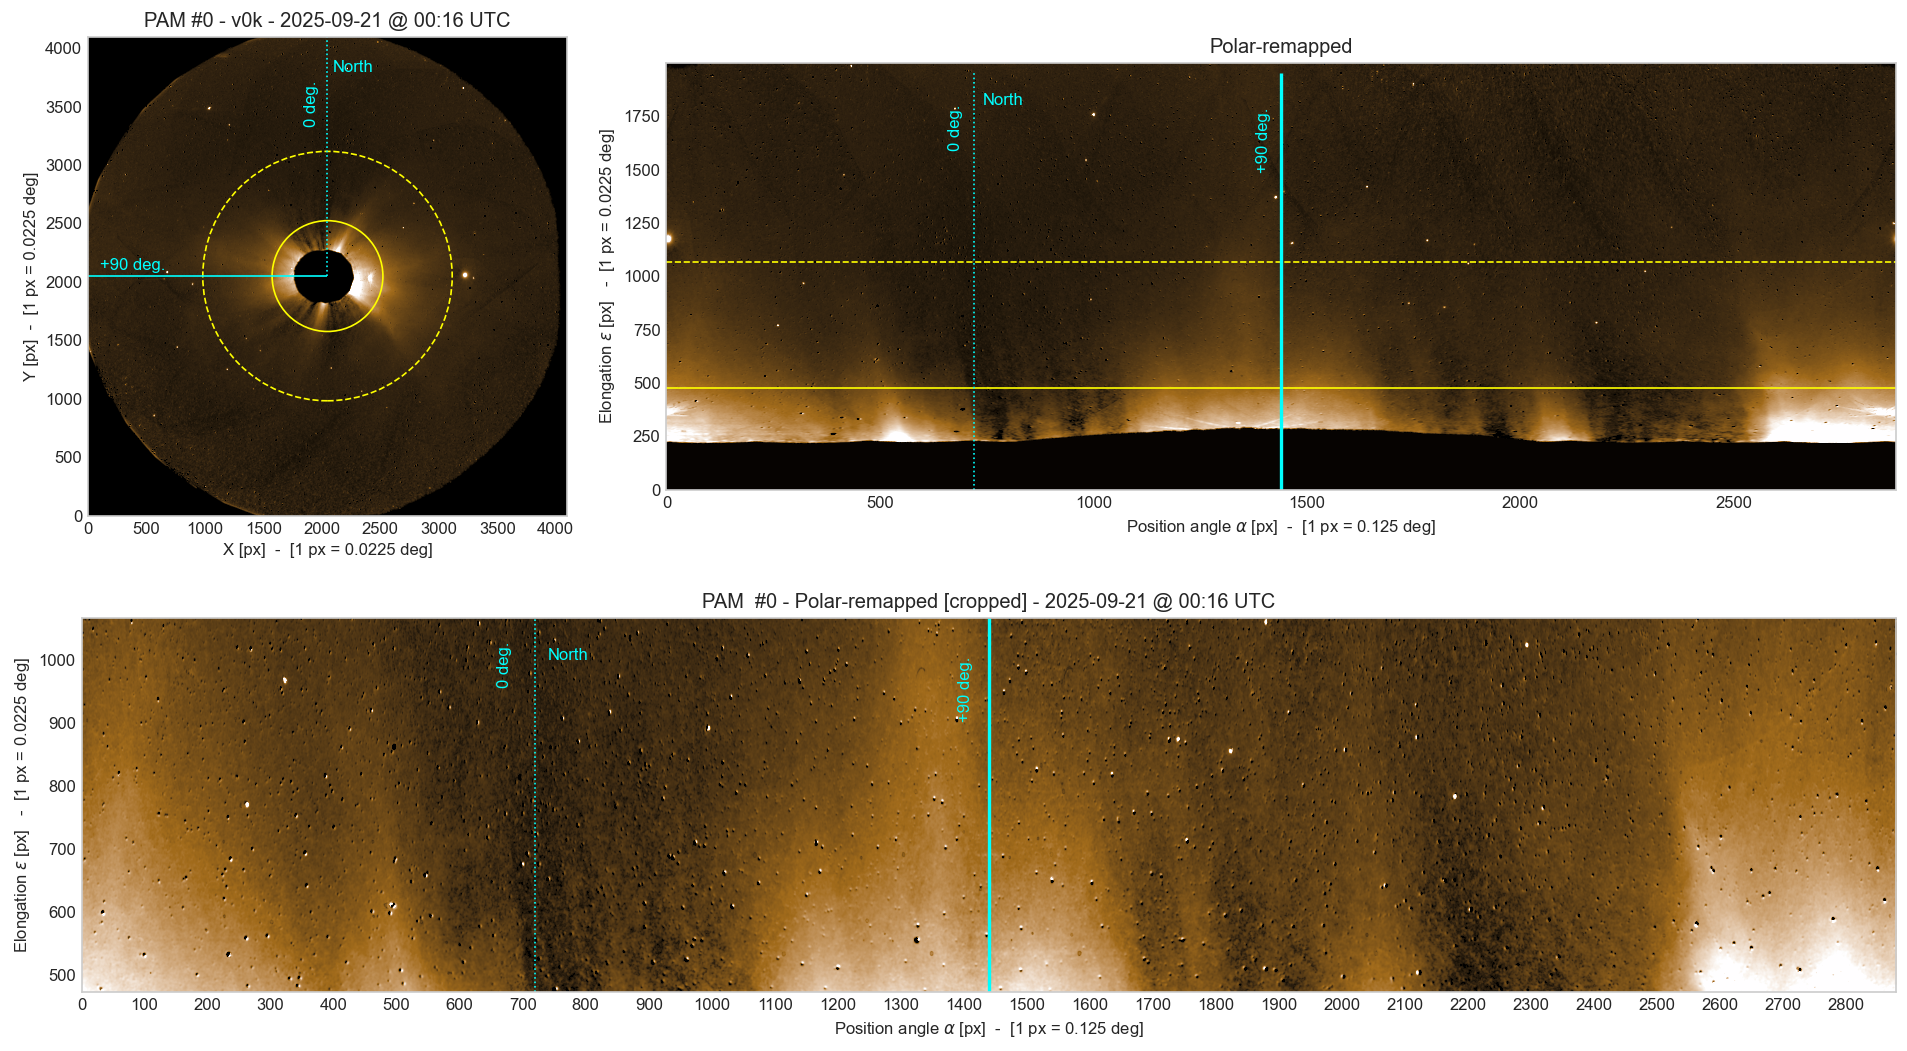

In [15]:
%matplotlib inline

# Load the first FITS file
idx = 0
image1, header1 = read_fits(files[idx], product=PRODUCT_CODE)

# Polar-transform the first image but include the crop and explicity preprocessing options
preprocess_noprep_dict={
    'remove_background' : False,
    'use_median' : False, # Wheter to use arithmetic mean or median
    'radial_rms_normalize' : False,
    'crop' : None,
}

# Get some global scaling values for the intensity based on the original image and polar remapped image
pmin0, pmax0 = 10, 99.9
vmax0 = np.percentile(image1, pmax0)
vmin0 = np.percentile(image1, pmin0)

# Polar-transform the first image, do not pre-proprocess further
polar_image1 = polar_remap(image1, header1, polar_nr, num_azimuth_bins, az_bin)
# For the polar-remmapped cropped image
pmin1, pmax1 = 1, 99.5
vmax1 = np.percentile(polar_image1, pmax1)
vmin1 = np.percentile(polar_image1, pmin1)

# For the polar-remmapped cropped image
polar_image2 = polar_image1[r_low:r_high, :]
pmin2, pmax2 = 1, 99.5
vmax2 = np.percentile(polar_image2, pmax2)
vmin2 = np.percentile(polar_image2, pmin2)

plt.close('all')
fig = plot_previews(image1, header1, polar_image1, polar_image2, r_low, r_high, vmax0=vmax0, vmin0=vmin0, vmax1=vmax1, vmin1=vmin1, vmin2=vmin2, vmax2=vmax2,
    idx=0, savefig=True)

plt.show()


## Pre-processing before correlating the images

Illustrate the standardization of the data, and the data range of the pre-processed data. 
Pre-proprocessed data have annuli of zero-mean or "zero-median" and standard dev. of 1. 
Due to many outliers, this notebook uses the median.

Additionally, the image is cropped during pre-processing

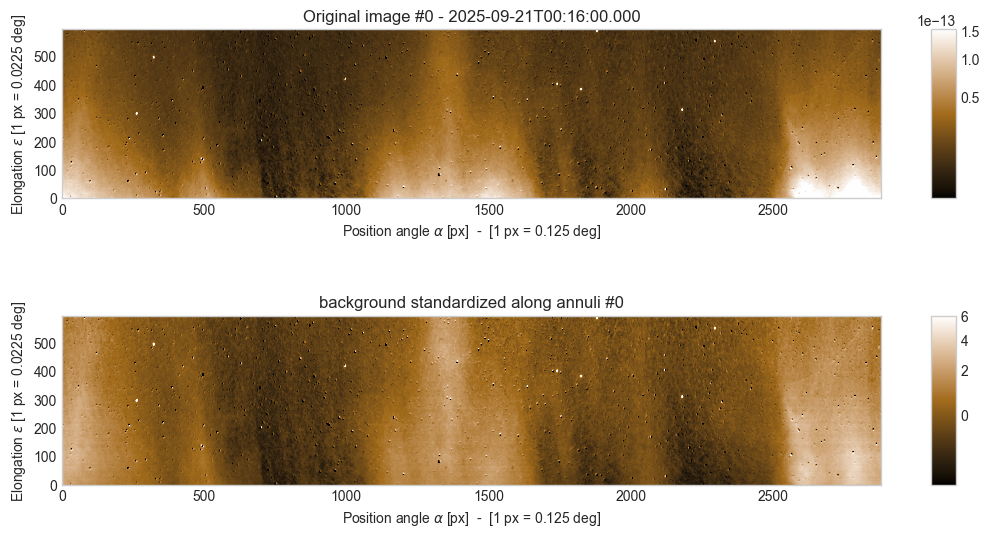

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.close('all')
# Load the first FITS file
file = files[0]

image1, header1 = read_fits(file, product=PRODUCT_CODE)

# Preprocessing options
# Polar-transform and crop, do not pre-proprocess further
polar_im1 = polar_remap(image1.copy(), header1, polar_nr, num_azimuth_bins, az_bin)
polar_im1 = polar_im1[r_low:r_high, :]

# Pre-process: subtract mean (or median) and divide by rms (aka standardization or z-score normalization)
prep_dict={
    'use_median' : True, # Whether to use arithmetic mean or median
    'rms_normalize' : True,
    'crop' : [r_low, r_high],
}
polar_im2 = preprocess_image(image1.copy(), header1, polar_nr, num_azimuth_bins, az_bin,
                             polar_header=False, **prep_dict)


fig, axs = plt.subplots(2,1, figsize=(10, 6))
im0 = axs[0].imshow(polar_im1,  origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=vmin2, vmax=vmax2))
axs[0].set_title(f"Original image #{idx} - {header1['DATE-OBS']}")
axs[0].set_xlabel(r'Position angle $\alpha$ [px]  -  [1 px = 0.125 deg]')
axs[0].set_ylabel(r'Elongation $\epsilon$ [1 px = 0.0225 deg]')
# Create a divider for the existing axes
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size="3%", pad=0.5)

im1 = axs[1].imshow(polar_im2,  origin='lower', cmap=cmap_punch, norm=PowerNorm(gamma=1/2.2, vmin=-1, vmax=6))
axs[1].set_title(f'background standardized along annuli #{idx}')
axs[1].set_xlabel(r'Position angle $\alpha$ [px]  -  [1 px = 0.125 deg]')
axs[1].set_ylabel(r'Elongation $\epsilon$ [1 px = 0.0225 deg]')
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="3%", pad=0.5)

plt.colorbar(im0, cax=cax0)
plt.colorbar(im1, cax=cax1)

for ax in axs:
    ax.grid(False)

plt.tight_layout()


In [20]:
TIME_CADENCE_SEC = 32 * 60  # time cadence of punch PAM images in seconds (32 minutes for L3 CAM)

delta_t = 1  # Time offset in frames between images.
sparsity = 1  # [Obsolete?] Frame skip interval for averaging - used to be 2 with STEREO COR2
n_ofs = 101 # 151  # Number of spatial offsets for cross-correlation = 151 in Craig's code for STEREO/COR2

# Pixel offset increment per sample- with the PUNCH greater pixel scale, we may need less than STEREO COR2.
# But because of the stars, we may need more...
delta_px = 1  
expected_kps_windspeed = 300  # Expected wind speed in km/s
velocity_azimuth_bins = 36  # Number of azimuthal bins in the output flow maps
# Sanity-check that the binning of the velocity is consistent with the azimuth dimension
assert polar_naz % velocity_azimuth_bins == 0

# Expected windspeed in pixels between consecutive frames
expected_px_windspeed =  expected_kps_windspeed / km_per_px * TIME_CADENCE_SEC 
# Central offset of the correlation.
central_offset = int(delta_t * expected_px_windspeed) # equiv. to of0 in Craig's code
x_pix = delta_px * (np.arange(n_ofs) - (n_ofs - 1) / 2) + central_offset
x_kps = x_pix / central_offset * expected_kps_windspeed

km_per_px_sec = km_per_px / TIME_CADENCE_SEC

print('Central offset = ', central_offset) # Should be 9 unless we've changed something above

# Preprocessing options
preprocess_dict={
    'use_median' : True, # Wheter to use arithmetic mean or median
    'rms_normalize' : True,
    'crop' : [r_low, r_high],
}

Central offset =  9


### Run the correlation for just a few frames over [50-80] Rs

In [21]:
acc_0_11 = accumulate_cross_correlation_across_frames(files[0:11], delta_t, sparsity, n_ofs, max_radius_deg,
                                                    num_azimuth_bins, az_bin, delta_px, central_offset,
                                                    **preprocess_dict)

Frame 0 vs frame 1
Frame 1 vs frame 2
Frame 2 vs frame 3
Frame 3 vs frame 4
Frame 4 vs frame 5
Frame 5 vs frame 6
Frame 6 vs frame 7
Frame 7 vs frame 8
Frame 8 vs frame 9
Frame 9 vs frame 10


x-index of global max: 41
speed at global max: 0.0 km/s


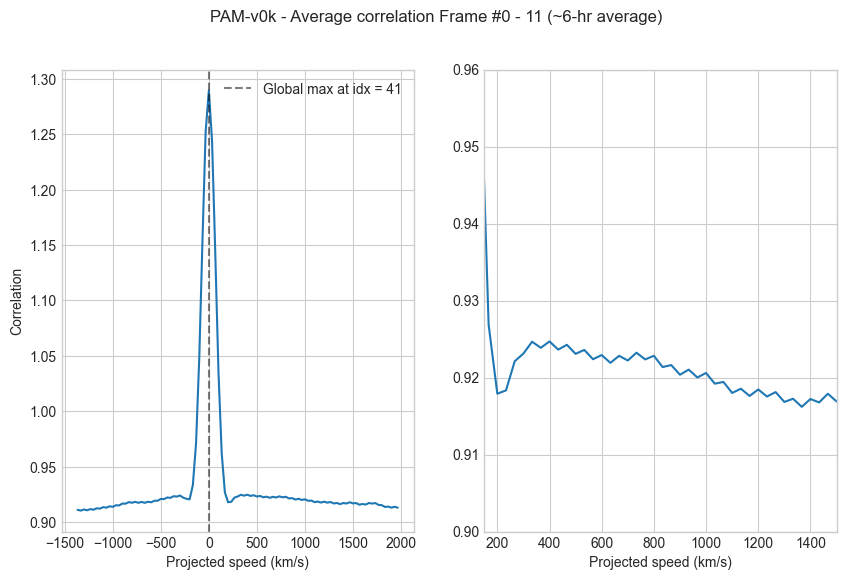

In [24]:
avcor_0_11= acc_0_11.mean(axis=2).mean(axis=1)
argmax = np.argmax(avcor_0_11)
speed_peak1 = x_kps[argmax]

print(f'x-index of global max: {argmax}')
print(f'speed at global max: {speed_peak1} km/s')


fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.suptitle(f'{PRODUCT_CODE}-{VERSION_CODE} - Average correlation Frame #0 - 11 (~6-hr average)')
# Plot with autocorrelation vs. speed, including several bands with error bars
axs[0].plot(x_kps, avcor_0_11)
axs[0].set_ylabel('Correlation')
axs[0].set_xlabel('Projected speed (km/s)')
# Add the line at argmax
axs[0].axvline(x=speed_peak1, ymin=0, ymax=1, color='k', linestyle='--', alpha=0.5,
               label=f'Global max at idx = {argmax}')
axs[0].legend(loc='upper right')

axs[1].plot(x_kps, avcor_0_11, label=f'avcor')
axs[1].set_xlabel('Projected speed (km/s)')
axs[1].set_xlim([150, 1500])
axs[1].set_ylim([0.9, 0.96])


# plt.savefig(f'{PRODUCT_CODE}{VERSION_CODE}_avcor_0-11')

The plot above shows a "sawtooth" pattern on the correlation profile. It is under investigation and may change in future data versions. 

The plots below shows one possible cause of the sawtooth.

In [25]:
mean_int = []
for idx, file in enumerate(files[0:50]):
    image_idx, header_idx = read_fits(file, product=PRODUCT_CODE)
    polar_im2 = preprocess_image(image_idx.copy(), header_idx, polar_nr, num_azimuth_bins, az_bin,
                                 **preprocess_dict)
    mean_int.append(np.mean(polar_im2))

(-30.0, 30.0)

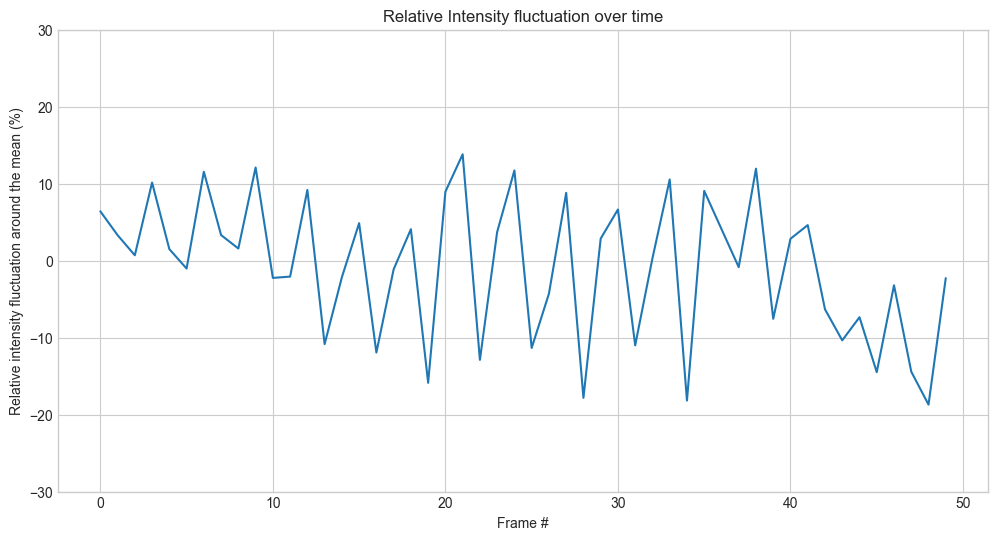

In [26]:
# Showing the source of the sawtooth pattern
mean_int_arr = np.array(mean_int)
fig, axs = plt.subplots(1, 1, figsize=(12,6))
axs.plot((mean_int_arr - mean_int_arr.mean())/mean_int_arr * 100)
axs.set_xlabel('Frame #')
axs.set_ylabel('Relative intensity fluctuation around the mean (%)')
axs.set_title('Relative Intensity fluctuation over time')
axs.set_ylim([-30, 30])

### Let's explore the correlation for different azimuthal slices and time windows. 

The slices are selected to include different solar wind "domains".

In [27]:
# Select three subsets of files. The 3rd one (60:90) has a CME around x-axis pixel 2600
subsets = [files[0:30], files[30:60], files[60:90]]

accs = []
for subset_files in subsets:
    acc = accumulate_cross_correlation_across_frames(subset_files, delta_t, sparsity, n_ofs, max_radius_deg,
                                                    num_azimuth_bins, az_bin, delta_px, central_offset,
                                                    **preprocess_dict)
    accs.append(acc)

Frame 0 vs frame 1
Frame 1 vs frame 2
Frame 2 vs frame 3
Frame 3 vs frame 4
Frame 4 vs frame 5
Frame 5 vs frame 6
Frame 6 vs frame 7
Frame 7 vs frame 8
Frame 8 vs frame 9
Frame 9 vs frame 10
Frame 10 vs frame 11
Frame 11 vs frame 12
Frame 12 vs frame 13
Frame 13 vs frame 14
Frame 14 vs frame 15
Frame 15 vs frame 16
Frame 16 vs frame 17
Frame 17 vs frame 18
Frame 18 vs frame 19
Frame 19 vs frame 20
Frame 20 vs frame 21
Frame 21 vs frame 22
Frame 22 vs frame 23
Frame 23 vs frame 24
Frame 24 vs frame 25
Frame 25 vs frame 26
Frame 26 vs frame 27
Frame 27 vs frame 28
Frame 28 vs frame 29
Frame 0 vs frame 1
Frame 1 vs frame 2
Frame 2 vs frame 3
Frame 3 vs frame 4
Frame 4 vs frame 5
Frame 5 vs frame 6
Frame 6 vs frame 7
Frame 7 vs frame 8
Frame 8 vs frame 9
Frame 9 vs frame 10
Frame 10 vs frame 11
Frame 11 vs frame 12
Frame 12 vs frame 13
Frame 13 vs frame 14
Frame 14 vs frame 15
Frame 15 vs frame 16
Frame 16 vs frame 17
Frame 17 vs frame 18
Frame 18 vs frame 19
Frame 19 vs frame 20
Frame 20 

Below we wake three azimuthal slices of the cross-correlation and plot them over the three time windows defined above


In [29]:
# Define the three azimuth slices (in pixels)
azmin_max = [[0, 80], [2300, 2380], [2560, 2640]]

# Get an annuli from ~50 Rs (r_low in pixels) to 60 Rs. (10-Rs width)
e_50_60 = calc_ylims(55, 5, arcsec_per_px) # This function needs the half-width -> 5 Rs
# Elongation pixel coordinate at 60 Rs
y60 = e_50_60[1]

# Get the local pixel coordinate, starting from r_low (reminder: image was cropped)
elong_range1_top = y60 - r_low

# average correlation over the azimuth (axis=2), and over the elongation axis (axis=1)
avcors_slices = [[acc[:,0:elong_range1_top, azmin_max[i][0]:azmin_max[i][1]].mean(axis=2).mean(axis=1) for acc in accs]
                 for i in range(3)]


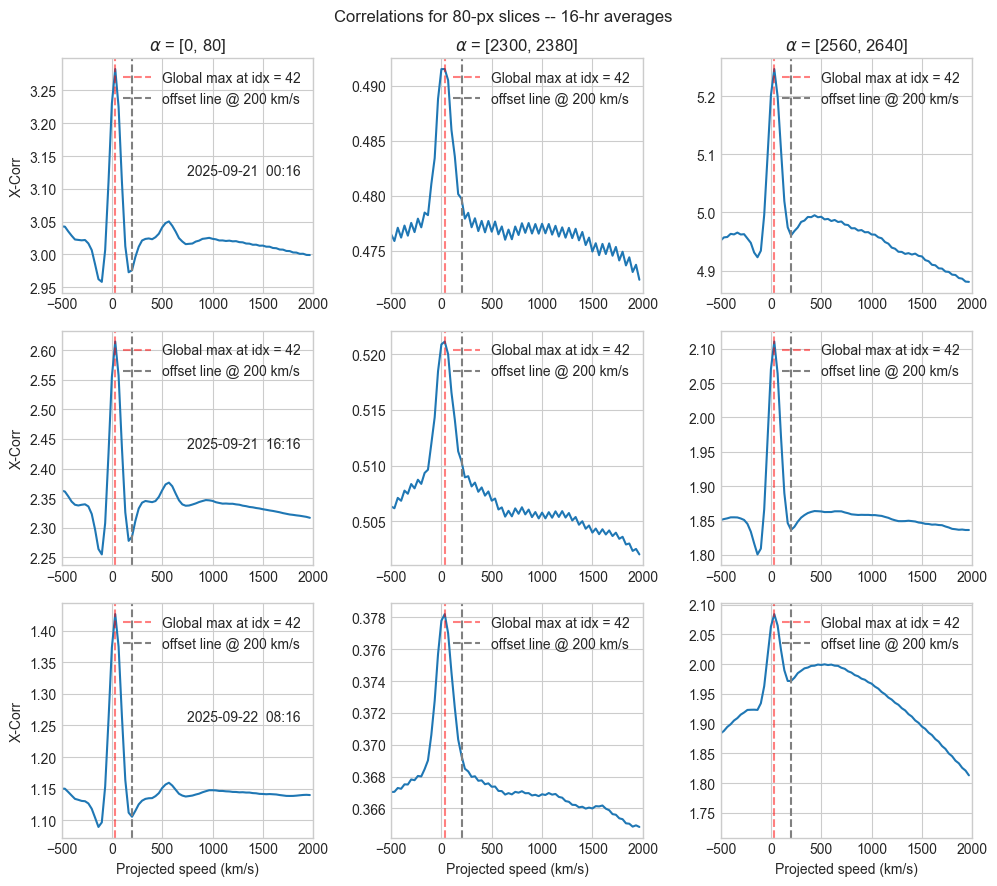

<Figure size 640x480 with 0 Axes>

In [33]:
%matplotlib inline

offset_speed = 200

plt.close('all')
fig, axs = plt.subplots(3, 3, figsize=(10, 9))
# Plot with autocorrelation vs. speed, including several bands with error bars
plt.suptitle('Correlations for 80-px slices -- 16-hr averages')

# Plots Row varies with frame # (time), columns vary with azimuth (position angle)
for t in range(3): # t for time
    subset_files = subsets[t]
    header_r1 = read_header(subset_files[0])
    time_r1 = header_r1['DATE-OBS'][0:-7]
    header_r2 = read_header(subset_files[-1])
    time_r2 = header_r2['DATE-OBS'][0:-7]

    for s in range(3): # s for space

        axs[t, s].plot(x_kps, avcors_slices[s][t], color='tab:blue')
        axs[t, s].set_xlim([-500, 2000])
        axs[t, s].grid(True)

        # Find global max and add the line at argmax
        argmax = np.argmax(avcors_slices[s][t])
        global_peak = x_kps[argmax]

        axs[t, s].axvline(x=global_peak, ymin=0, ymax=1, color='red', linestyle='--', alpha=0.5,
                       label=f'Global max at idx = {argmax}')

        axs[t, s].axvline(x=offset_speed, ymin=0, ymax=1, color='gray', linestyle='--',
                       label=f'offset line @ {offset_speed} km/s')

        axs[t, s].legend(loc='upper right')

        if t == 0:
            axs[t, s].set_title(fr'$\alpha$ = {azmin_max[s]}')
        if t == 2:
            axs[t, s].set_xlabel('Projected speed (km/s)')
        if s == 0:
            axs[t, s].set_ylabel(f'X-Corr')

    axs[t, 0].text(0.5, 0.5, time_r1.replace('T', '  '), transform=axs[t, 0].transAxes)

plt.tight_layout()
plt.show()
# plt.savefig('v0k_avcor_slices.png')

### Can we consistently get past the global max to find physically meaningful local max of flow speed? See validation work with J-Map (time-distance plots) from Ritesh Patel


- Simplest "naive" solution: seek max correlation only past uppermost non-solar peak location
highly dependent on product level code and version number.

- Currently, we consider negative speeds unphysical

- This can be re-visited with higher-calibration levels

spike_offset_idx = 47 px


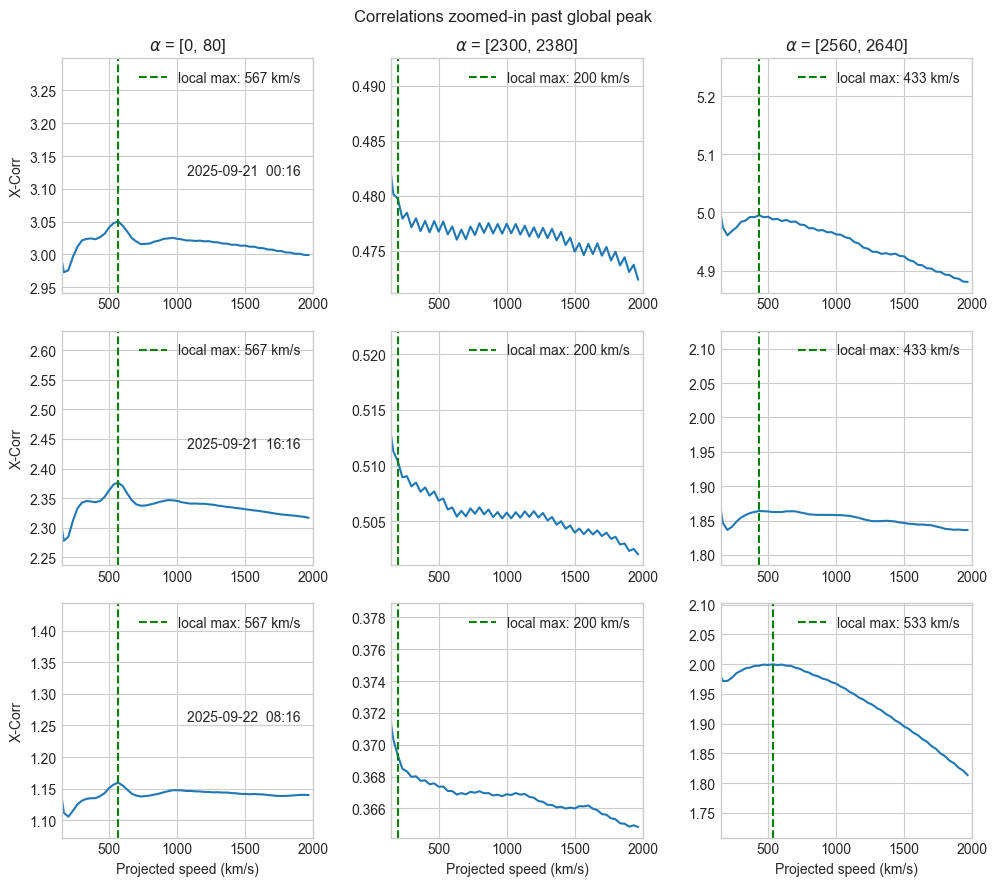

In [34]:
%matplotlib inline

# What x-index is our offset speed?
spike_offset_idx = int(np.where(x_kps >= offset_speed)[0][0])
print(f'spike_offset_idx = {spike_offset_idx} px')

plt.close('all')
fig, axs = plt.subplots(3, 3, figsize=(10, 9))
# Plot with autocorrelation vs. speed, including several bands with error bars
plt.suptitle(f'Correlations zoomed-in past global peak')

# Plots Row varies with frame # (time), columns vary with azimuth (position angle)
for t in range(3): # t for time
    subset_files = subsets[t]
    header_r1 = read_header(subset_files[0])
    time_r1 = header_r1['DATE-OBS'][0:-7]
    header_r2 = read_header(subset_files[-1])
    time_r2 = header_r2['DATE-OBS'][0:-7]

    for s in range(3): # s for space

        axs[t, s].plot(x_kps, avcors_slices[s][t], color='tab:blue')
        axs[t, s].set_xlim([offset_speed-50, 2000])
        axs[t, s].grid(True)

        # Find secondary max and add the line
        argmax = avcors_slices[s][t][spike_offset_idx:].argmax()
        local_peak_1 = x_kps[argmax + spike_offset_idx]

        axs[t, s].axvline(x=local_peak_1, ymin=0, ymax=1, color='green', linestyle='--',
                       label=f'local max: {round(local_peak_1)} km/s')

        axs[t, s].legend(loc='upper right')

        if t == 0:
            axs[t, s].set_title(fr'$\alpha$ = {azmin_max[s]}')
        if t == 2:
            axs[t, s].set_xlabel('Projected speed (km/s)')
        if s == 0:
            axs[t, s].set_ylabel(f'X-Corr')

    axs[t, 0].text(0.5, 0.5, time_r1.replace('T', '  '), transform=axs[t, 0].transAxes)

plt.tight_layout()
plt.show()
# plt.savefig('v0k_avcor_slices_zoom.png')

In [35]:
def correl_peak_speed(acc, ymin_max, spike_offset_idx):
    ''' gets the speed from the correlation array '''
    
    # bin size over latitude. 
    azimuth_bin_size = acc.shape[2] // velocity_azimuth_bins 
    # Average correlation signal over the selected annuli 
    acc_k = acc[:, int(ymin_max[0]):int(ymin_max[1]) + 1, ...].mean(axis=1)
    # Reshape the average correlation array for max efficiency of the per-bin velocity measurement
    avcor_rbins_theta = acc_k.reshape(acc_k.shape[0], azimuth_bin_size, velocity_azimuth_bins)
    # Get the 1st correlation peak past the non-physical ones (detector, flat-field pattern, stars etc...)
    speedmax_idx_per_thbin = np.array(
                [avcor_rbins_theta[spike_offset_idx:, :, i].argmax(axis=0) + spike_offset_idx for i in range(velocity_azimuth_bins)])
    # Map to physical speed
    speedmax_per_theta = x_kps[speedmax_idx_per_thbin]
    # Average the speed over the azimuthal bins
    avg_speed = speedmax_per_theta.mean(axis=1)
    # Get the standard deviation for that same bin. Assume Poisson statistics for resulting error
    sigma = speedmax_per_theta.std(axis=1) / np.sqrt(azimuth_bin_size)

    return avg_speed, sigma

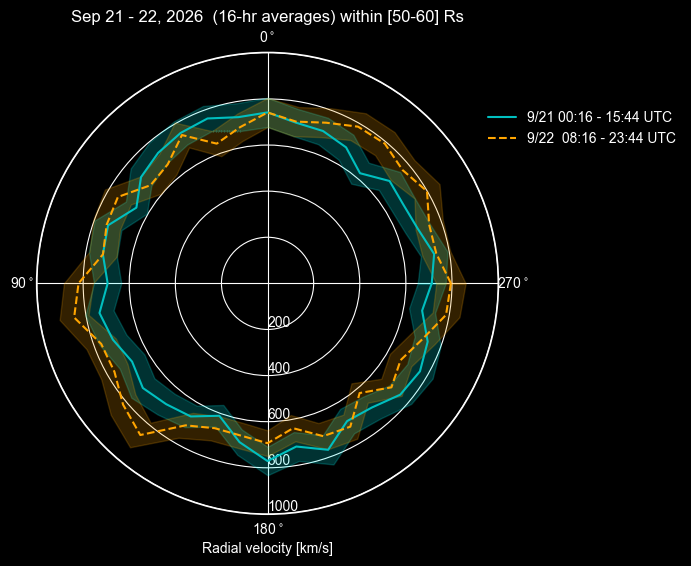

In [36]:
### 1st time slice

annuli = [0, y60]  # annuli coordinates in pixels - here, corresponds to 50-60 Rs
avg_speed_0, sigma_0 = correl_peak_speed(accs[0], annuli, spike_offset_idx)

# Prep the polar plot
signal0 = np.append(avg_speed_0, avg_speed_0[0])
error0 = np.append(sigma_0, sigma_0[0])

# Azimuthal coordinates for the polar plot
thetas = np.linspace(0, 2 * np.pi, velocity_azimuth_bins + 1) 

plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(1, 1, 1, projection="polar")
ax.plot(thetas, signal0, "c-", label=f'9/21 00:16 - 15:44 UTC')
ax.fill_between(thetas, signal0 - error0, signal0 + error0, alpha=0.2, color="cyan")


ax.set_title(f"Sep 21 - 22, 2026  (16-hr averages) within [50-60] Rs")
ax.set_ylim(0, 1.3 * avg_speed_0.max())
ax.set_rlabel_position(270)
ax.set_xlabel('Radial velocity [km/s]')


### 2nd time slice - with CME

avg_speed_2, sigma_2 = correl_peak_speed(accs[2], annuli, spike_offset_idx)

# Prep the polar plot
signal2 = np.append(avg_speed_2, avg_speed_2[0])
error2 = np.append(sigma_2, sigma_2[0])

ax.plot(thetas, signal2, color='orange', ls="--", label=f'9/22  08:16 - 23:44 UTC')
ax.fill_between(thetas, signal2 - error2, signal2 + error2, alpha=0.2, color="orange")

# Specify angles in degrees
angles = [0, 90, 180, 270]
# Specify custom labels for those angles
labels = [r'270$^\circ$', r'0$^\circ$', r'90$^\circ$', r'180$^\circ$']
ax.set_thetagrids(angles, labels=labels)

plt.legend(bbox_to_anchor=(0.95, 0.9))

plt.savefig('flow_maps_time_slices_TWO_TIME_SLICES.png')